In [1]:
# Import necessary libraries

import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

import xarray as xr

import torch
import deepwave
from deepwave import elastic
import deepwave.common as dwc

from parameters_py.config import (
                                MODEL_NAME,FOLDER_OUTPUT,
                                NZ,NX,DX,DZ,
                                FREQ,NT,DT,NT,ACCURACY,
                                MIN_FREQ,SIGMA,
                                PML_WIDTH,N_SHOTS,N_SHOTS_PER_SHOT,D_SOURCE,
                                FIRST_SOURCE,SOURCE_DEPTH,N_RECEIVERS_PER_SHOT,
                                D_RECEIVERS,FIRST_RECEIVERS,RECEIVERS_DEPTH
				                )

from CODES.modeling import create_acquisition_geometry,create_source_amplitudes,simulate_elastic_shots

from CODES.dispersion_curves import calculate_dispersion_image,pick_dispersion_curve_hessian


Reading configuration file: ./config_file.cnf


# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [2]:
data_path = FOLDER_OUTPUT+MODEL_NAME+'/DATA/'

### Directory for saving figures: 

In [3]:
figures_path = FOLDER_OUTPUT+MODEL_NAME+'/FIGURES/'

# Synthetic Surface Wave Forward Modeling and Dispersion

### Computation of Synthetic Seismic Data and Phase-Velocity Curves

To construct the synthetic surface-wave data and extract Rayleigh phase-velocity dispersion curves, our workflow is divided into two main computational steps: 
- Full-waveform simulation, and 
- Automated dispersion curve extraction. 

For the full-waveform forward modeling, we utilize Deepwave, a computationally efficient, PyTorch-based elastic wave propagator. This allows us to simulate the actual wave propagation, accurately capturing complex surface wave phenomena across our finite-difference grid. 

To process the resulting synthetic shot gathers, we compute dispersion images by transforming the time-space ($t-x$) data into the frequency-phase velocity ($f-c$) domain using the Phase-Shift Method, following the approach outlined in the MASWavesPy package (Ólafsdóttir et al., 2024). Amplitude normalization is applied in the frequency domain to eliminate geometric attenuation effects, isolating the phase shifts. Subsequently, the fundamental mode dispersion curves are automatically extracted using Hessian matrix eigenvalue analysis. This technique builds a 2D Hessian matrix for the energy spectrum to evaluate local curvature (second-order derivatives), identifying continuous energy ridges with sub-pixel precision. A 2D Gaussian filter is applied prior to extraction to suppress noise and stabilize the eigenvalue calculations.

### Acquisition Geometry and Model Parameters

Based on our specific experimental geometry, the synthetic seismic data acquisition is simulated along a 2D profile of 100 meters in length and 2 meters in depth. To properly model the surface waves, we employ a free-surface boundary condition at the top of the model, with perfectly matched layers absorbing reflections on the remaining boundaries. 

The finite-difference time-domain (FDTD) simulation uses an 8th-order spatial accuracy scheme. The acquisition parameters are defined as follows:

*   Grid Dimensions: Horizontal and vertical cell sizes of 0.1 m, resulting in a 1000 x 20 grid.
*   Source Setup: 9 independent seismic shots positioned at the surface. The shots are spaced 10 meters apart, utilizing a 100 Hz central frequency Ricker wavelet.
*   Receiver Array: Each shot is recorded by an array of 48 active surface receivers. The receivers are spaced 20 centimeters apart, with an source-receiver offset of 10 meters.
*   Time Integration: The simulation computes 20,000 discrete time steps of 0.01 ms (0.00001 s) to strictly satisfy the CFL stability condition, yielding a total recording time of 0.2 seconds per shot.

**References:**
- Ólafsdóttir, E. Á., Bessason, B., Erlingsson, S., & Kaynia, A. M. (2024). A Tool for Processing and Inversion of MASW Data and a Study of Inter-session Variability of MASW. Geotechnical Testing Journal, 47, 1006-1025. [DOI: 10.1520/GTJ20230380]
- Xiaoping, H., Jiashun, Y., Jianlong, Y. et al. An automatic algorithm for surface wave dispersion curve picking based on Hessian matrix attributes. Sci Rep 15, 21595 (2025). [DOI: 10.1038/s41598-025-04954-w]
- [Deepwave Elastic Propagator](https://ausargeo.com/deepwave/elastic)
- [MASWavesPy GitHub Repository](https://github.com/Mazvel/maswavespy/tree/main)


## Importing the 2D model previously created

In [4]:
ds = xr.open_zarr(data_path+"seismic_model.zarr")

In [5]:
ds

<xarray.Dataset> Size: 970kB
Dimensions:    (z: 20, x: 1200)
Coordinates:
    depth      (z) float64 160B dask.array<chunksize=(20,), meta=np.ndarray>
    distance   (x) float64 10kB dask.array<chunksize=(1200,), meta=np.ndarray>
Dimensions without coordinates: z, x
Data variables:
    density    (z, x) float64 192kB dask.array<chunksize=(20, 1200), meta=np.ndarray>
    formation  (z, x) int64 192kB dask.array<chunksize=(20, 1200), meta=np.ndarray>
    vp         (z, x) float64 192kB dask.array<chunksize=(20, 1200), meta=np.ndarray>
    vpvs       (z, x) float64 192kB dask.array<chunksize=(20, 1200), meta=np.ndarray>
    vs         (z, x) float64 192kB dask.array<chunksize=(20, 1200), meta=np.ndarray>
Attributes:
    DX:                      0.1
    DZ:                      0.1
    NX:                      1200
    NZ:                      20
    num_layers:              3
    vs_per_layer_m_s:        [237, 520, 327]
    vp_per_layer_m_s:        [1156.56, 1206.3999999999999, 1219.71]
    density_per_layer_gcm3:  [1.3861145032395439, 1.4259534250656936, 1.43636...
    basement_vp_m_s:         [1600.0]
    basement_vs_m_s:         800.0
    basement_vpvs:           2.0
    basement_density_g_cm3:  [1.69711661056]

## Creating geometry for modeling the seismic acquisition:

In [6]:
# device: use GPU when available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### Wavelet

#### Deepwave's built-in **Ricker wavelet**.


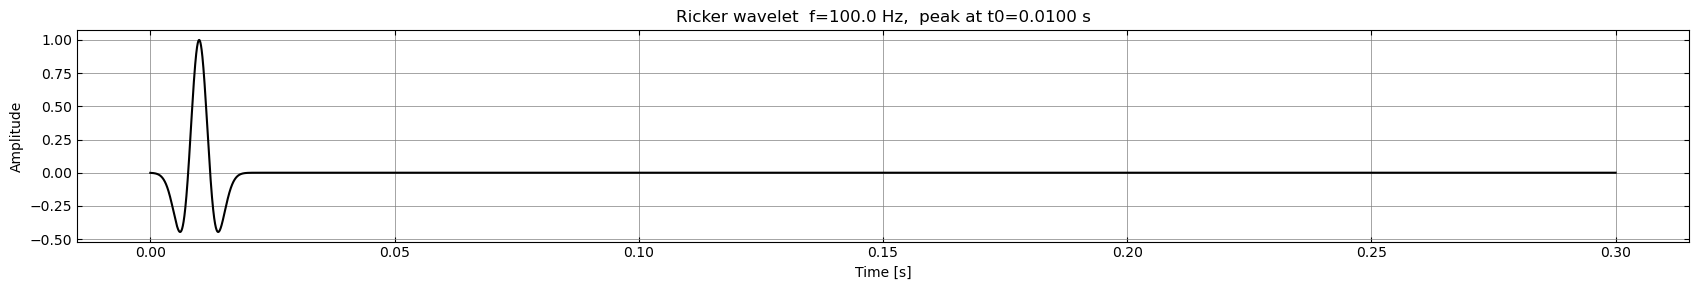

In [7]:
source_amplitudes = create_source_amplitudes(
    freq=FREQ,
    nt=NT,
    dt=DT,
    n_shots=N_SHOTS,
    n_shots_per_shot=N_SHOTS_PER_SHOT,
    device=device,
    plot_wavelet=True,
    figures_path=figures_path)

## Elastic finite-difference modelling with Deepwave

For more information see: https://ausargeo.com/deepwave/example_forward_model

### Acquisition geometry

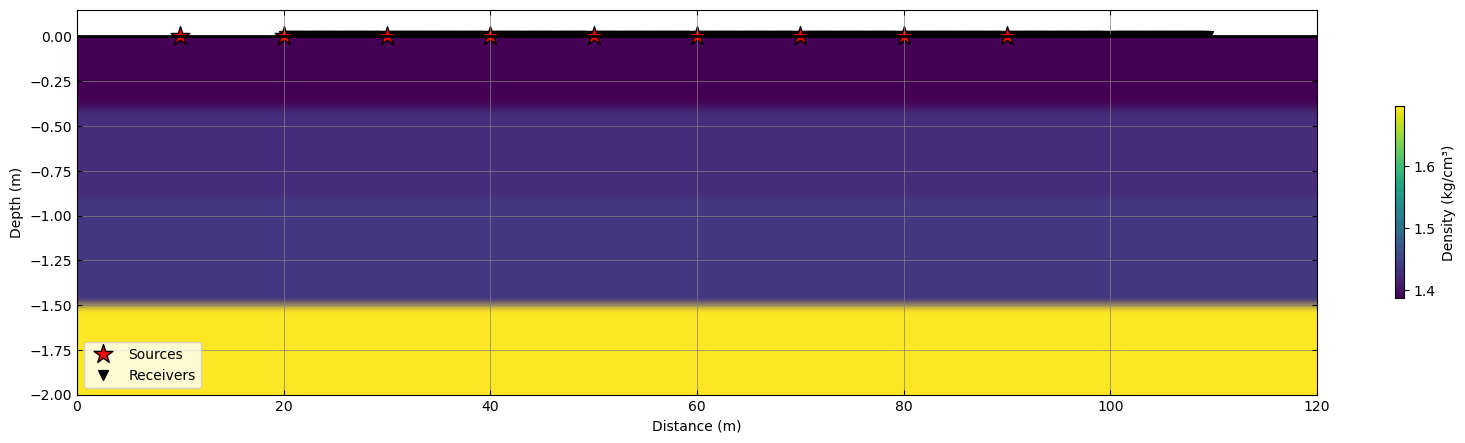

In [8]:
source_locations, receiver_locations = create_acquisition_geometry(
    n_shots=N_SHOTS,
    n_receivers_per_shot=N_RECEIVERS_PER_SHOT,
    d_source=D_SOURCE,
    d_receivers=D_RECEIVERS,
    first_source=FIRST_SOURCE,       # Updated spelling
    first_receiver=FIRST_RECEIVERS,  # Updated spelling
    source_depth=SOURCE_DEPTH,
    receiver_depth=RECEIVERS_DEPTH,
    n_shots_per_shot=N_SHOTS_PER_SHOT,
    device=device,
    plot_profile=True,
    data_to_plot=ds,
    figures_path=figures_path
)

## Forward modelling

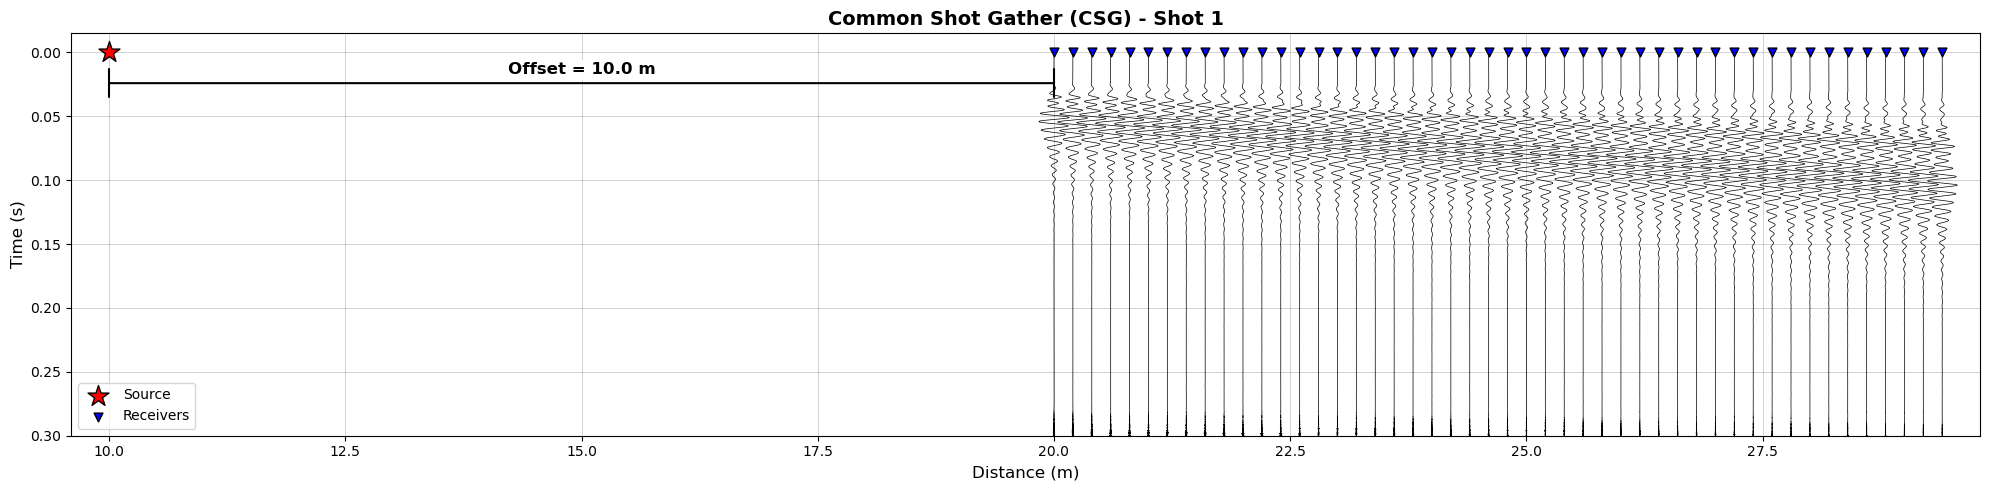

In [9]:
dtype = torch.float32

vp_tensor = torch.tensor(
    ds.vp.data.compute(),
    dtype=dtype,
    device=device
)

vs_tensor = torch.tensor(
    ds.vs.data.compute(),
    dtype=dtype,
    device=device
)

vpvs_tensor = torch.tensor(
    ds.vpvs.data.compute(),
    dtype=dtype,
    device=device
)

rho_tensor = torch.tensor(
    ds.density.data.compute(),
    dtype=dtype,
    device=device
)

output = simulate_elastic_shots(
    vp=vp_tensor,
    vs=vs_tensor,
    rho=rho_tensor,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    dx=DX,
    dz=DZ,
    dt=DT,
    pml_width=PML_WIDTH,
    pml_freq=FREQ,
    accuracy=ACCURACY,
    device=device,
    plot_shot_gathers=True,
    figures_path=figures_path)

## Extracts the fundamental surface wave dispersion curve from the created dispersion image 

## Create and save a dataframe with the observed data generated

In [10]:
output[0].shape

(48, 30000)

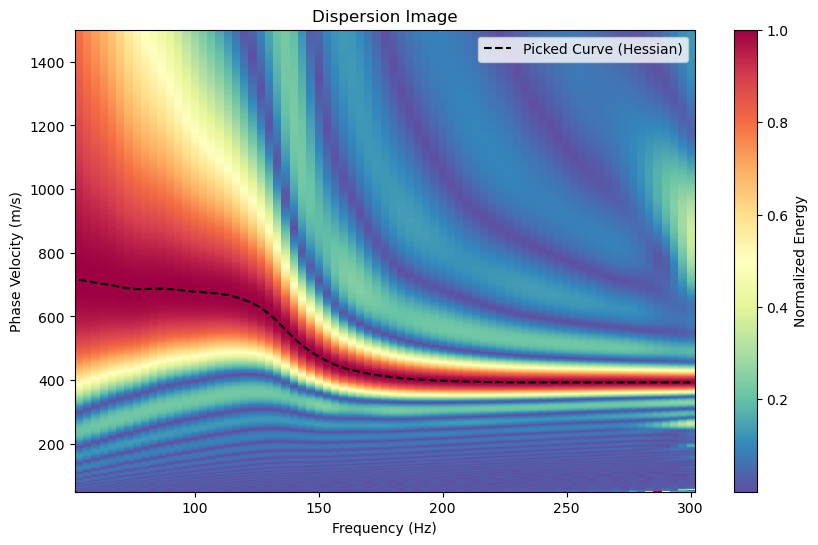

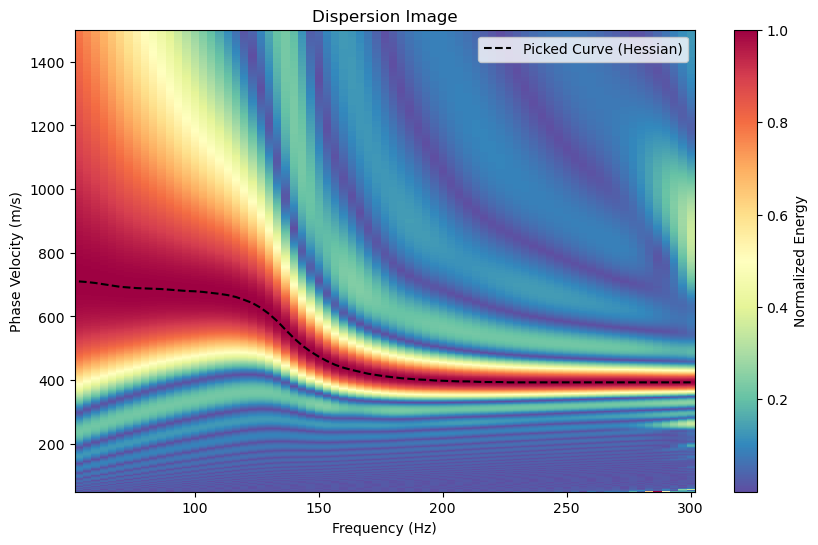

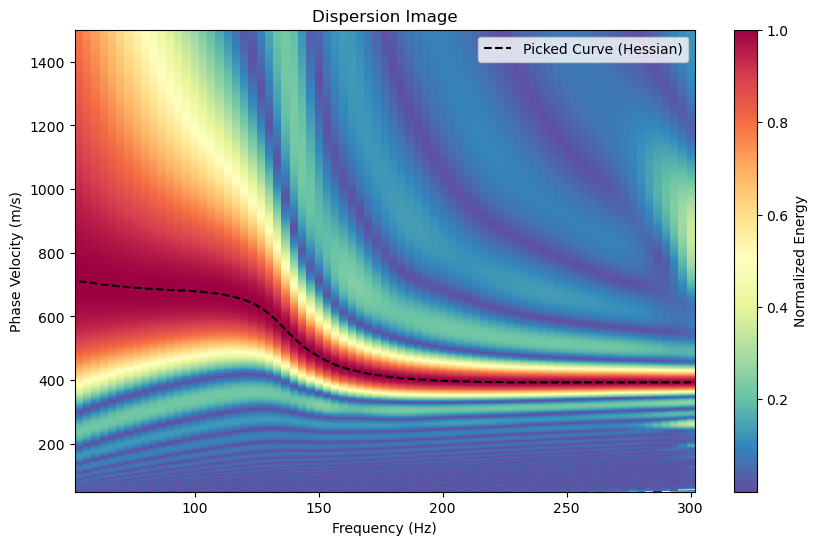

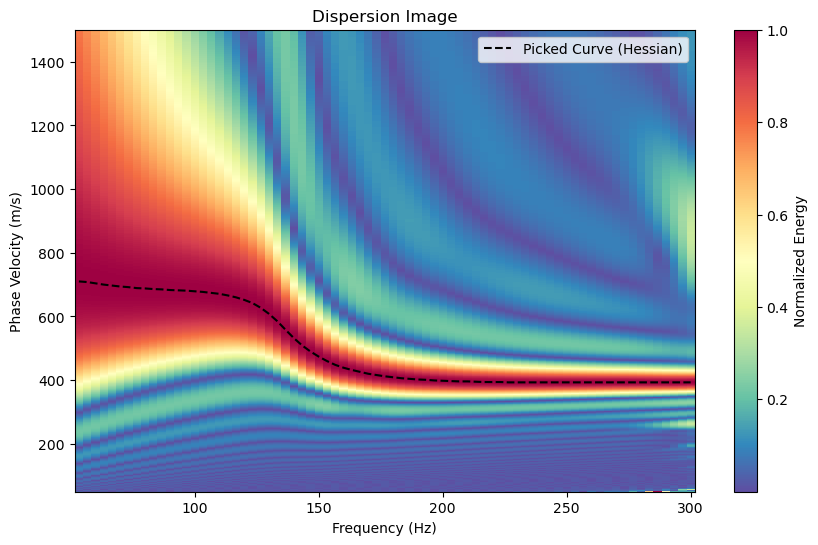

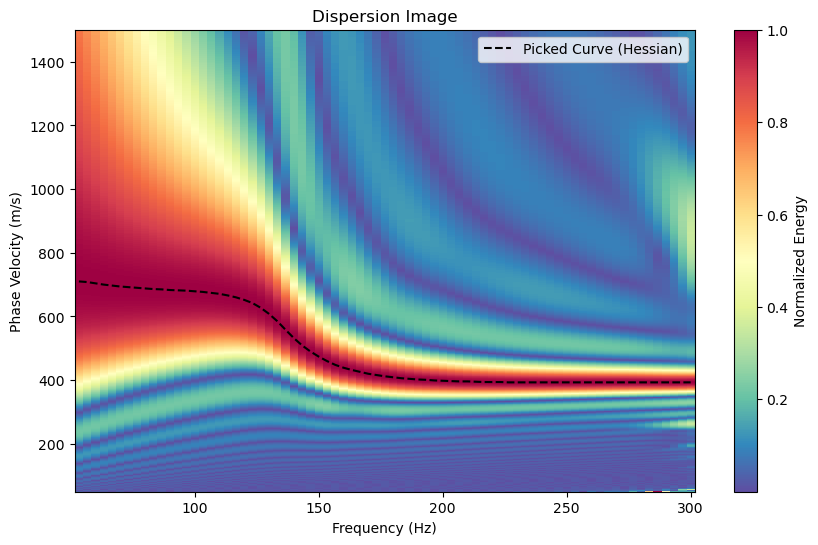

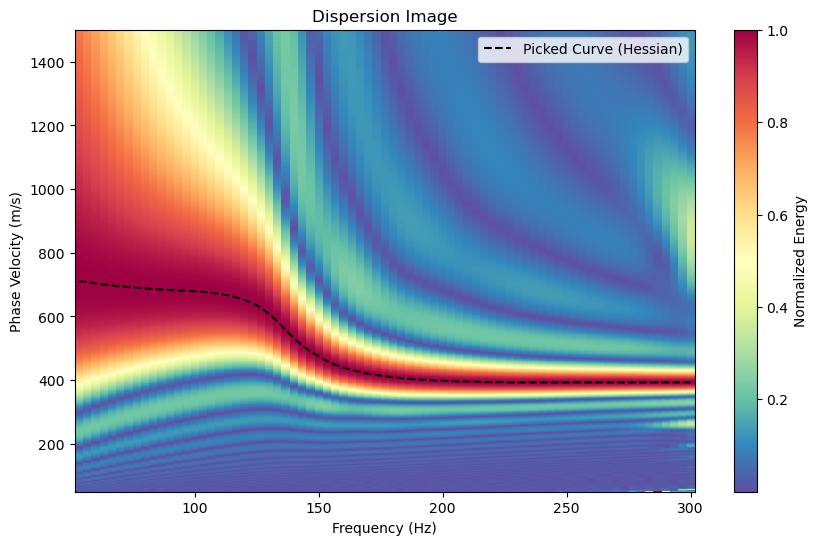

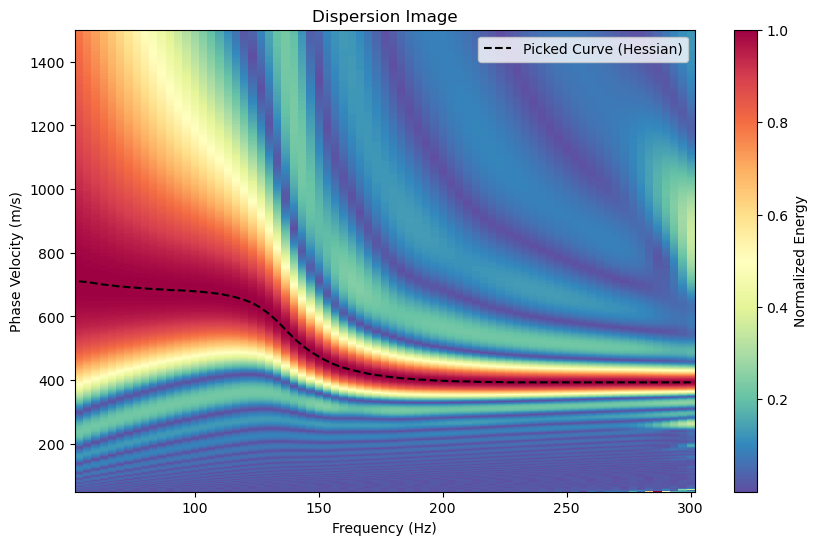

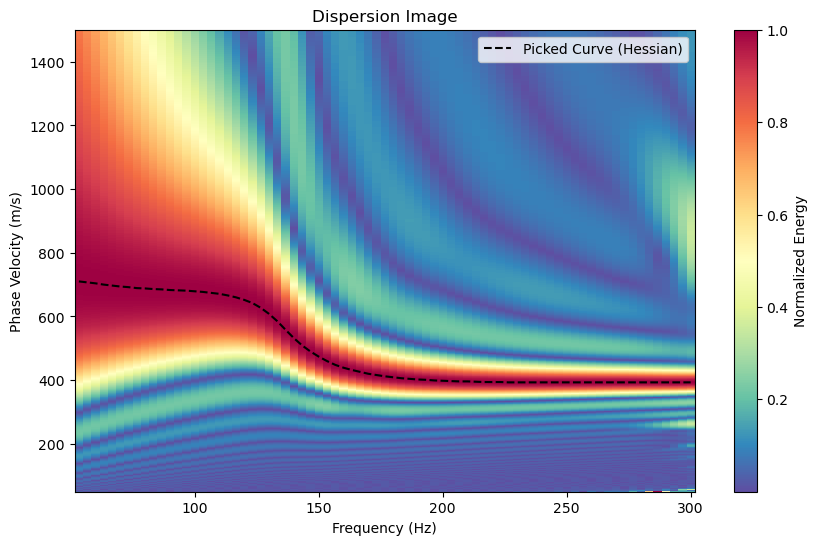

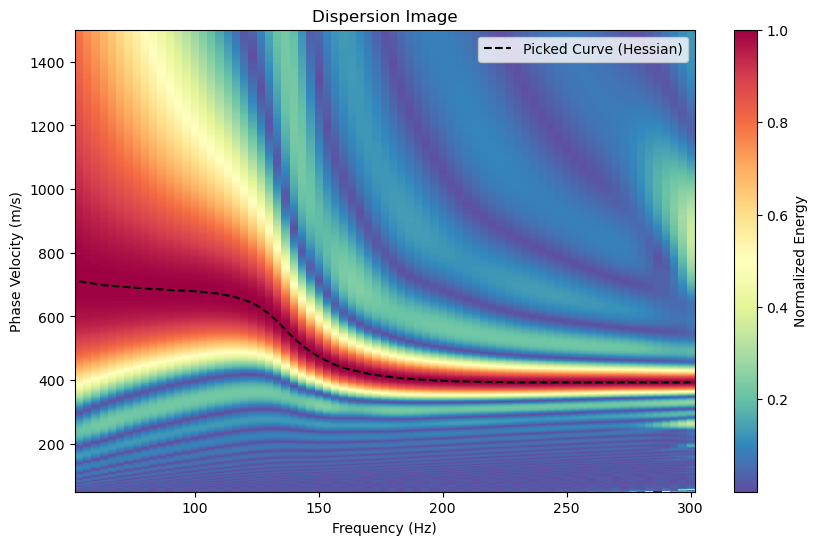

In [11]:
# 1. Inicializando as listas vazias
survey_lst = []
density_lst = []
vels_lst = []
vpvs_lst = []
depth_lst = []
dispersion_curve_lst = []
hz_lst = []

# Iterando sobre os tiros
for shot_id, data in enumerate(output):

    offsets_id = receiver_locations[...,-1].numpy()[shot_id]
    
    offsets = offsets_id*DX

    # Encontrando o índice do meio do perfil de receptores
    idx_mid = len(offsets_id)//2
    
    # 3. Extraindo os perfis 1D do xarray 'ds' no ponto médio (idx_mid)
    # O uso do .values garante que os arrays dask sejam computados/convertidos para numpy
    depth_1d = ds.depth.values
    density_1d = ds.density.isel(x=idx_mid).values
    vs_1d = ds.vs.isel(x=idx_mid).values
    vpvs_1d = ds.vpvs.isel(x=idx_mid).values
    
    # 4. Executando o Phase Shift
    freqs, v_phase, disp_img = calculate_dispersion_image(
        data=data.T, 
        nt=NT,
        dt=DT, 
        offsets=offsets, 
        c_min=50, 
        c_max=1500,
        dc=1,
        f_min=MIN_FREQ, 
        f_max=FREQ*3
    )

    picked_f, picked_v = pick_dispersion_curve_hessian(
        disp_img, freqs, v_phase, 
        sigma=SIGMA, min_freq=MIN_FREQ, plot_curve=True
    )
    
    # 5. Populando as listas para o banco de dados final
    survey_lst.append(round(offsets[idx_mid]))
    density_lst.append(density_1d)
    vels_lst.append(vs_1d)
    vpvs_lst.append(vpvs_1d)
    depth_lst.append(depth_1d)
    dispersion_curve_lst.append(picked_v)
    hz_lst.append(picked_f)

# 6. Agregando tudo no dicionário
dic_obs_data = {
    'survey': survey_lst,
    'density': density_lst,
    'velocity_s': vels_lst,
    'vpvs': vpvs_lst,
    'depth': depth_lst,
    'dispersion_curve': dispersion_curve_lst,
    'frequency': hz_lst
}

In [12]:
dic_obs_data

{'survey': [25, 35, 45, 55, 65, 75, 85, 95, 105],
 'density': [array([1.3861145 , 1.3861145 , 1.3861145 , 1.3861145 , 1.42595343,
         1.42595343, 1.42595343, 1.42595343, 1.42595343, 1.43636843,
         1.43636843, 1.43636843, 1.43636843, 1.43636843, 1.43636843,
         1.69711661, 1.69711661, 1.69711661, 1.69711661, 1.69711661]),
  array([1.3861145 , 1.3861145 , 1.3861145 , 1.3861145 , 1.42595343,
         1.42595343, 1.42595343, 1.42595343, 1.42595343, 1.43636843,
         1.43636843, 1.43636843, 1.43636843, 1.43636843, 1.43636843,
         1.69711661, 1.69711661, 1.69711661, 1.69711661, 1.69711661]),
  array([1.3861145 , 1.3861145 , 1.3861145 , 1.3861145 , 1.42595343,
         1.42595343, 1.42595343, 1.42595343, 1.42595343, 1.43636843,
         1.43636843, 1.43636843, 1.43636843, 1.43636843, 1.43636843,
         1.69711661, 1.69711661, 1.69711661, 1.69711661, 1.69711661]),
  array([1.3861145 , 1.3861145 , 1.3861145 , 1.3861145 , 1.42595343,
         1.42595343, 1.42595343, 1.4

In [13]:
obs_data = pd.DataFrame.from_dict(dic_obs_data)
obs_data.to_feather(data_path+'observed_data.feather')

In [18]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
import numpy as np

dtype = torch.float32

NEW_NX = 300

# Load your model parameters
vp_tensor = torch.tensor(ds.vp.data.compute(), dtype=dtype, device=device)[:, :NEW_NX]
vs_tensor = torch.tensor(ds.vs.data.compute(), dtype=dtype, device=device)[:, :NEW_NX]
vpvs_tensor = torch.tensor(ds.vpvs.data.compute(), dtype=dtype, device=device)[:, :NEW_NX]
rho_tensor = torch.tensor(ds.density.data.compute(), dtype=dtype, device=device)[:, :NEW_NX]

# Convert to Lamé parameters and buoyancy
lam, mu, buoyancy = dwc.vpvsrho_to_lambmubuoyancy(vp_tensor, vs_tensor, rho_tensor)

# Use only first source
source_amplitudes = source_amplitudes[:1]
source_locations = source_locations[:1]
receiver_locations = receiver_locations[:1]

# Get the actual number of time steps
nt = source_amplitudes.shape[-1]
print(f"Number of time steps (nt): {nt}")

# Set callback frequency
callback_frequency = 50  # Capture every 10 steps
print(f"Callback frequency: {callback_frequency}")

# Calculate number of snapshots
n_snapshots = (nt + callback_frequency - 1) // callback_frequency
print(f"Will capture up to {n_snapshots} snapshots")


# Get grid dimensions
ny, nx = vp_tensor.shape[-2:]
print(f"Grid dimensions: ny={ny}, nx={nx}")

# Storage for forward snapshots
forward_snapshots_vx = torch.zeros(n_snapshots, ny, nx)
forward_snapshots_vy = torch.zeros(n_snapshots, ny, nx)

class WavefieldCallback:
    def __init__(self):
        self.step = 0
        self.max_steps = n_snapshots
        self.vx_name = None
        self.vy_name = None
        
    def __call__(self, state):
        if self.step >= self.max_steps:
            return
        
        # Find wavefield names on first call - CRITICAL FIX HERE
        if self.vx_name is None:
            available_keys = list(state._wavefields.keys())
            print(f"Available wavefields: {available_keys}")
            
            # Select vx_0 and vy_0 specifically, NOT the memory variables
            # Memory variables start with 'm_' - we want to avoid those
            for key in available_keys:
                # Look for exact match 'vx_0' or 'vy_0'
                if key == 'vx_0':
                    self.vx_name = key
                elif key == 'vy_0':
                    self.vy_name = key
            
            # Fallback: select any key that is exactly 'vx' or 'vy' or ends with '_0'
            if self.vx_name is None:
                for key in available_keys:
                    if key in ['vx', 'vx_0', 'velocity_x'] and not key.startswith('m_'):
                        self.vx_name = key
                        break
            
            if self.vy_name is None:
                for key in available_keys:
                    if key in ['vy', 'vy_0', 'velocity_y'] and not key.startswith('m_'):
                        self.vy_name = key
                        break
            
            print(f"Using Vx: {self.vx_name} (should be 'vx_0')")
            print(f"Using Vy: {self.vy_name} (should be 'vy_0')")
        
        # Capture Vx - using the correct wavefield
        if self.vx_name:
            wavefield_vx = state.get_wavefield(self.vx_name)[0].cpu().clone()
            forward_snapshots_vx[self.step] = wavefield_vx
        
        # Capture Vy
        if self.vy_name:
            wavefield_vy = state.get_wavefield(self.vy_name)[0].cpu().clone()
            forward_snapshots_vy[self.step] = wavefield_vy
        
        self.step += 1
        
        # Print progress with actual amplitude
        if self.step % 100 == 0:
            max_amp = forward_snapshots_vx[self.step-1].max().item()
            print(f"Captured snapshot {self.step}/{self.max_steps}, Max amplitude: {max_amp:.6e}")

# Run simulation
print(f"\nRunning simulation...")
forward_callback = WavefieldCallback()

output = elastic(
    lam, mu, buoyancy,
    grid_spacing=[DZ, DX],
    dt=DT,
    source_amplitudes_y=source_amplitudes,
    source_locations_y=source_locations,
    receiver_locations_y=receiver_locations,
    pml_width=PML_WIDTH,
    pml_freq=FREQ,
    accuracy=ACCURACY,
    forward_callback=forward_callback,
    callback_frequency=callback_frequency
)

print(f"\nCaptured {forward_callback.step} snapshots")
print(f"Vx amplitude range: [{forward_snapshots_vx.min().item():.6e}, {forward_snapshots_vx.max().item():.6e}]")

# Get source and receiver positions
source_loc = source_locations[0]
source_x = source_loc[0, 1].cpu().numpy() * DX
source_z = source_loc[0, 0].cpu().numpy() * DZ

receivers = receiver_locations[0]
receiver_x = receivers[:, 1].cpu().numpy() * DX
receiver_z = receivers[:, 0].cpu().numpy() * DZ

print(f"Source at: ({source_x:.1f}m, {source_z:.1f}m)")
print(f"Receivers: {len(receiver_x)} receivers")

# Create visualization
print(f"\nCreating animation with {forward_callback.step} frames...")

# Use only captured snapshots
valid_snapshots = forward_snapshots_vx[:forward_callback.step]

# Calculate colorbar limits
vmax_abs = valid_snapshots.abs().max().item()
if vmax_abs > 0:
    vmax_sym = vmax_abs
else:
    vmax_sym = 1.0  # Fallback

print(f"Colorbar range: ±{vmax_sym:.6e}")

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot with symmetric colorbar
im = ax.imshow(valid_snapshots[0].T, cmap='seismic', 
                aspect='auto', vmin=-vmax_sym, vmax=vmax_sym,
                extent=[0, nx*DX, ny*DZ, 0],
                interpolation='bilinear')

cbar = plt.colorbar(im, ax=ax, label='Velocity (m/s)', fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)

# Plot source
ax.scatter(source_x, source_z, color='red', marker='*', s=300, 
            label='Source', edgecolor='yellow', linewidth=2, zorder=10)

# Plot receivers
ax.scatter(receiver_x, receiver_z, color='blue', marker='v', 
            s=50, label='Receivers', alpha=0.8, zorder=5)

# Highlight surface receivers
surface_mask = receiver_z == 0
if np.any(surface_mask):
    ax.scatter(receiver_x[surface_mask], receiver_z[surface_mask], 
                color='cyan', marker='v', s=60, label='Surface Receivers', 
                edgecolor='white', linewidth=1, zorder=6)

ax.set_xlabel("X Distance (m)", fontsize=12)
ax.set_ylabel("Z Depth (m)", fontsize=12)
ax.set_title("Elastic Wavefield Propagation - Vx Component", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

# Time text
time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, color='white',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle="round", facecolor='black', alpha=0.7),
                    verticalalignment='top')

# Amplitude text
amp_text = ax.text(0.02, 0.92, '', transform=ax.transAxes, color='white',
                    fontsize=10, bbox=dict(boxstyle="round", facecolor='black', alpha=0.5),
                    verticalalignment='top')

def update(frame):
    time_step = frame * callback_frequency
    time_sec = time_step * DT
    current_amp = valid_snapshots[frame].max().item()
    
    im.set_array(valid_snapshots[frame].T)
    time_text.set_text(f'Time: {time_sec:.3f}s (Step: {time_step}/{nt})')
    amp_text.set_text(f'Max amplitude: {current_amp:.3e}')
    
    return [im, time_text, amp_text]

# Create animation
anim = animation.FuncAnimation(fig, update, frames=forward_callback.step,
                                interval=50, blit=True)

# Save as GIF
save_path_gif = Path(figures_path) / "wavefield_propagation.gif"
anim.save(save_path_gif, writer='pillow', fps=20, dpi=100)
print(f"✅ Animation saved to {save_path_gif}")

# Save as MP4 if possible
try:
    save_path_mp4 = Path(figures_path) / "wavefield_propagation.mp4"
    anim.save(save_path_mp4, writer='ffmpeg', fps=20, dpi=100)
    print(f"✅ Video saved to {save_path_mp4}")
except:
    pass

# Create snapshot montage
fig2, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

snapshot_frames = [0, forward_callback.step//5, 2*forward_callback.step//5, 
                    3*forward_callback.step//5, 4*forward_callback.step//5, 
                    forward_callback.step-1]

for idx, frame in enumerate(snapshot_frames):
    if frame < forward_callback.step:
        ax2 = axes[idx]
        time_step = frame * callback_frequency
        time_sec = time_step * DT
        
        im2 = ax2.imshow(valid_snapshots[frame].T, cmap='seismic',
                        vmin=-vmax_sym, vmax=vmax_sym, aspect='auto',
                        extent=[0, nx*DX, ny*DZ, 0])
        ax2.set_title(f't = {time_sec:.3f}s')
        ax2.set_xlabel("X (m)")
        ax2.set_ylabel("Z (m)")
        ax2.scatter(source_x, source_z, color='red', marker='*', s=100)
        ax2.scatter(receiver_x, receiver_z, color='blue', marker='v', s=20, alpha=0.5)
        plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig(Path(figures_path) / 'wavefield_snapshots.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"✅ Snapshot montage saved to {Path(figures_path) / 'wavefield_snapshots.png'}")

plt.close(fig)
print("\n✅ All visualizations completed successfully!")


Number of time steps (nt): 30000
Callback frequency: 50
Will capture up to 600 snapshots
Grid dimensions: ny=20, nx=300

Running simulation...
Available wavefields: ['vy_0', 'sigmayy_0', 'sigmaxy_0', 'm_vyy_0', 'm_vyx_0', 'm_vxy_0', 'm_sigmayyy_0', 'm_sigmaxyy_0', 'm_sigmaxyx_0', 'vx_0', 'sigmaxx_0', 'm_vxx_0', 'm_sigmaxxx_0']
Using Vx: vx_0 (should be 'vx_0')
Using Vy: vy_0 (should be 'vy_0')
Captured snapshot 100/600, Max amplitude: 1.071707e-06
Captured snapshot 200/600, Max amplitude: 7.625476e-07
Captured snapshot 300/600, Max amplitude: 1.143263e-07
Captured snapshot 400/600, Max amplitude: 1.592463e-07
Captured snapshot 500/600, Max amplitude: 1.024934e-05
Captured snapshot 600/600, Max amplitude: 2.389425e-03

Captured 600 snapshots
Vx amplitude range: [-6.994484e-03, 3.530780e-03]
Source at: (10.0m, 0.0m)
Receivers: 48 receivers

Creating animation with 600 frames...
Colorbar range: ±6.994484e-03
✅ Animation saved to /media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/d